# Formations by ball zone

Where does each player stand depending on where the ball is? This notebook splits the pitch into 9 ball zones (3 thirds x 3 lanes) and draws a team's average shape for each one.

Run from the `notebooks/` folder or the repo root. Needs `data/processed/roles/` (from `src/roles.py`).

In [1]:
%matplotlib inline
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "analysis").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "analysis"))

import pandas as pd
import matplotlib.pyplot as plt
from formation_plot import draw_pitch, meta

## 1. Load one match

Each row is one player in one frame (5 frames per second). `x, y` are already flipped so the team always attacks to the right (+x), with its left side at +y. `ball_x, ball_y` are flipped the same way. `role_player` is the slot, named after the player who fills it most.

In [2]:
MATCH, TEAM = 2007721, 870      # CC Mariners
r = pd.read_parquet(ROOT / f"data/processed/roles/{MATCH}.parquet")
print(r.shape)
r.head()

(337080, 15)


,match_id,frame,period,team_id,player_id,x,y,detected,ball_x,ball_y,state,slot,rx,ry,role_player
0,2007721,436,1,870,10549,-13.31,5.180000,True,2.66,21.889999,in,0,-6.71,0.520000,10549
1,2007721,436,1,870,29856,-3.21,12.200000,True,2.66,21.889999,in,6,3.39,7.540000,795509
2,2007721,436,1,870,34423,-12.68,-16.959999,False,2.66,21.889999,in,2,-6.08,-21.620001,34423
3,2007721,436,1,870,51668,6.28,8.660000,True,2.66,21.889999,in,3,12.88,4.000000,51668
4,2007721,436,1,870,51683,-13.81,19.680000,True,2.66,21.889999,in,8,-7.21,15.020000,795511


## 2. One team, first half, frames with a ball position

First half only: substitutes take over slots in the second half and would show up as extra dots. The ball is sometimes off camera with no position; those frames can't go in a zone.

In [3]:
r = r[(r.team_id == TEAM) & (r.period == 1)]
r = r.dropna(subset=["ball_x", "ball_y"])

## 3. Ball zones

The pitch is 105 m long, so thirds split at ±17.5 m. It's 68 m wide, so lanes split at ±11.3 m. Right is negative y because the team attacks to the right. The ±999 catches balls slightly outside the lines.

Check: no empty cells, and the middle third has the most rows.

In [4]:
r["third"] = pd.cut(r.ball_x, [-999, -17.5, 17.5, 999],
                    labels=["Defensive", "Middle", "Attacking"])
r["lane"] = pd.cut(r.ball_y, [-999, -11.3, 11.3, 999],
                   labels=["Right", "Centre", "Left"])

r.groupby(["state", "third", "lane"], observed=True).size().unstack()

lane             Right  Centre  Left
state third                         
in    Defensive   2140    5370  1860
      Middle      6140    6140  8430
      Attacking   3690    1180  2980
out   Defensive   8050    2430  1350
      Middle     13020    5240  8790
      Attacking   1760    5650  2710

## 4. Average position of each slot in each zone

Use `x, y` (position on the pitch), not `rx, ry` (position relative to the team's centre, which role assignment needed).

Count frames with `nunique`, not `size`: each frame has 10 player rows, so `size` counts 10 times too much.

Check: 90 rows (9 zones x 10 slots).

In [5]:
def zone_shapes(r, state):
    d = r[r.state == state]
    zones = (d.groupby(["third", "lane", "role_player"], observed=True)
               .agg(x=("x", "mean"), y=("y", "mean"))
               .reset_index())
    ball = (d.groupby(["third", "lane"], observed=True)
              .agg(bx=("ball_x", "mean"), by=("ball_y", "mean"),
                   frames=("frame", "nunique")))
    return zones, ball

zones, ball = zone_shapes(r, "out")
print(len(zones))

90


## 5. Draw the 9 zones

Rows are lanes (Left on top, because left is +y), columns are thirds. The black dot is the ball's average position. Zones with under 10 seconds of data are skipped.

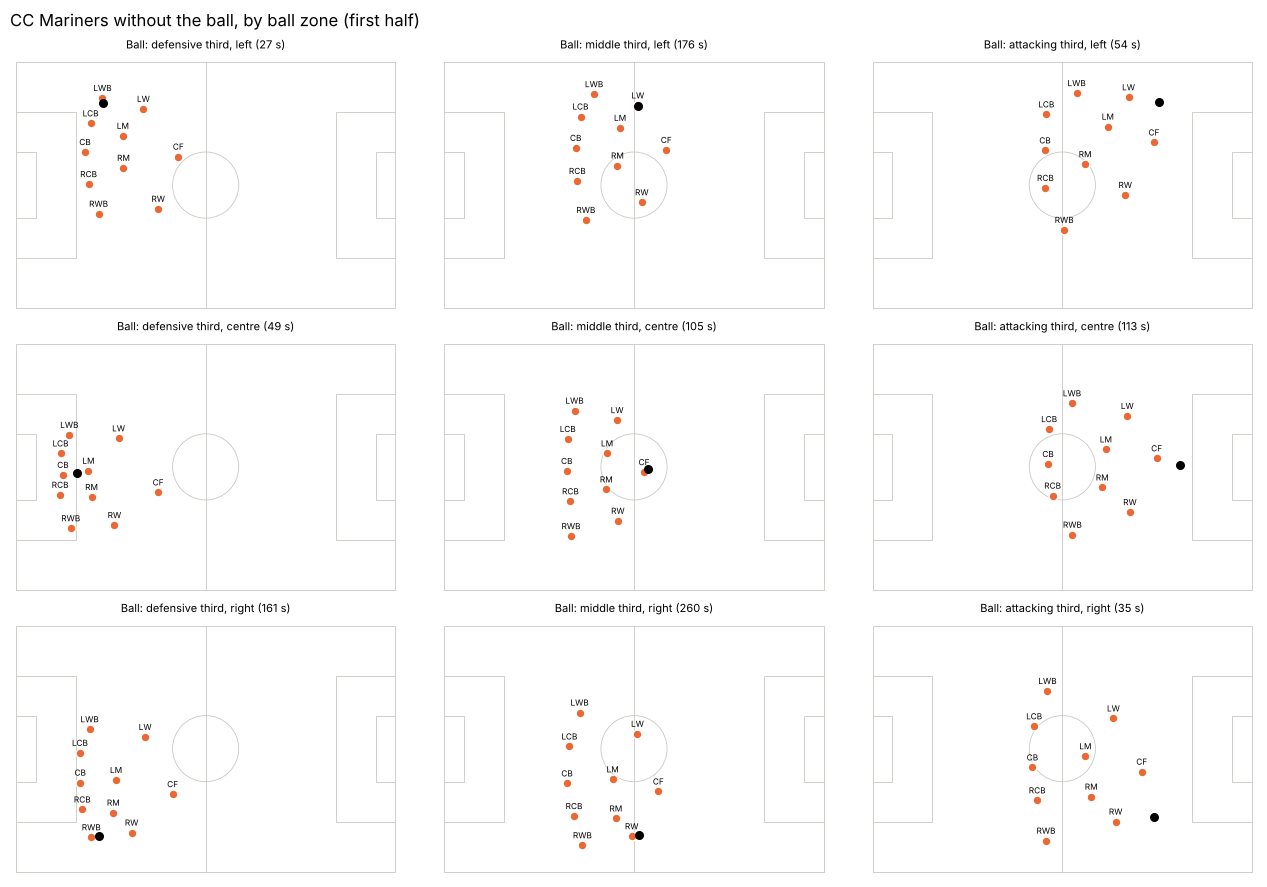

In [6]:
COLORS = {"out": "#eb6834", "in": "#2a78d6"}
LABEL = {"out": "without the ball", "in": "with the ball"}

def plot_zones(match, team, state, r=None):
    roles, names, teams = meta(match)
    if r is None:
        r = pd.read_parquet(ROOT / f"data/processed/roles/{match}.parquet")
        r = r[(r.team_id == team) & (r.period == 1)].dropna(subset=["ball_x", "ball_y"])
        r["third"] = pd.cut(r.ball_x, [-999, -17.5, 17.5, 999],
                            labels=["Defensive", "Middle", "Attacking"])
        r["lane"] = pd.cut(r.ball_y, [-999, -11.3, 11.3, 999],
                           labels=["Right", "Centre", "Left"])
    zones, ball = zone_shapes(r, state)

    fig, axes = plt.subplots(3, 3, figsize=(13, 9))
    for i, lane in enumerate(["Left", "Centre", "Right"]):
        for j, third in enumerate(["Defensive", "Middle", "Attacking"]):
            ax = axes[i, j]
            draw_pitch(ax, lw=0.6)
            if (third, lane) not in ball.index or ball.loc[(third, lane), "frames"] < 50:
                ax.set_title(f"{third}, {lane}: too few frames", fontsize=8)
                continue
            b = ball.loc[(third, lane)]
            z = zones[(zones.third == third) & (zones.lane == lane)]
            ax.scatter(z.x, z.y, s=40, color=COLORS[state], edgecolor="white", zorder=3)
            for _, p in z.iterrows():
                ax.annotate(roles.get(p.role_player, "?"), (p.x, p.y), xytext=(0, 5),
                            textcoords="offset points", ha="center", fontsize=6)
            ax.scatter(b.bx, b.by, s=30, color="black", zorder=4)
            ax.set_title(f"Ball: {third.lower()} third, {lane.lower()} "
                         f"({b.frames / 5:.0f} s)", fontsize=8)
    fig.suptitle(f"{teams[team]} {LABEL[state]}, by ball zone (first half)", x=0.02, ha="left")
    fig.tight_layout()
    return fig

fig = plot_zones(MATCH, TEAM, "out", r)

Things to check: the block slides toward the ball; it drops into a deep back five when the ball is near its own goal and presses past halfway when the ball is in the attacking third; every pitch has exactly 10 dots.

## 6. Same team with the ball

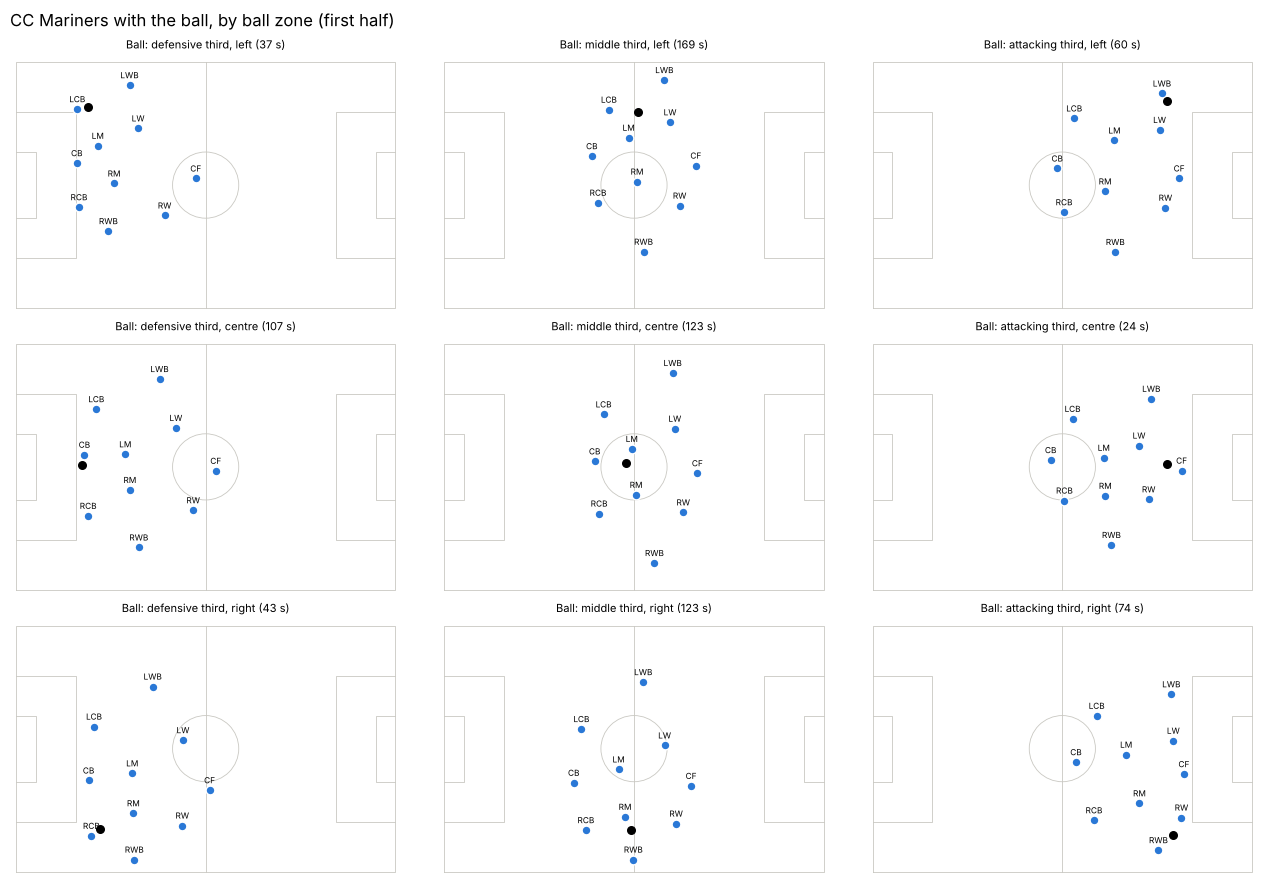

In [7]:
fig = plot_zones(MATCH, TEAM, "in", r)

## 7. Another team

Match and team ids are in the titles of `figures/formations_overview.png`.

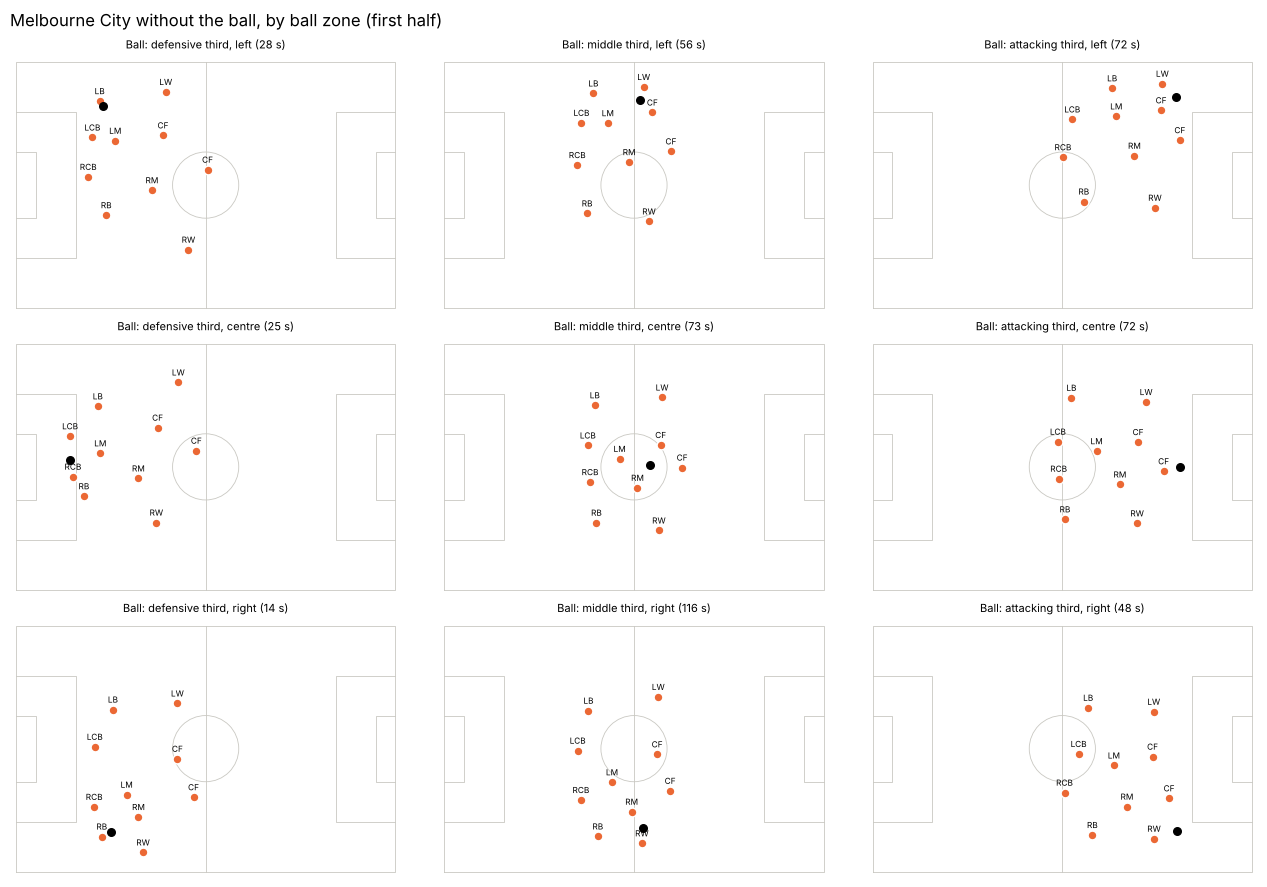

In [8]:
fig = plot_zones(2006229, 2380, "out")    # Melbourne City

## Next

1. **Use both halves.** Link each second half slot to the first half slot it replaced (same role, nearest average position), so substitutes inherit the slot instead of adding a new one.
2. **Combine all of a team's matches.** Slots are named after players, which change between matches, so label each slot with the official position of its player (from `match.json`) and group by that.